# Day 6 — Statistics for Data Science
## Hypothesis Testing and A/B Experiment Analysis

Imagine an online shop changes its checkout page.

- **Group A** sees the old page.
- **Group B** sees the new page.

We want to know:

1. Does the new page change average session time?
2. Does the new page change conversion rate?

We will create pretend data, explore it, run statistical tests, and explain the result in simple business language.

> This is a learning project using synthetic data. Synthetic data means we create it ourselves.

## 1. Simple statistics dictionary

| Term | Easy meaning |
|---|---|
| Sample | A small group we observe |
| Control group | The old version |
| Treatment group | The new version |
| Mean | Average |
| Hypothesis | A claim we want to test |
| Null hypothesis | “There is no difference” |
| Alternative hypothesis | “There is a difference” |
| p-value | How surprising our result is if there is no difference |
| Confidence interval | A range of plausible values |
| Statistical significance | Evidence that a result is unlikely to be random chance |

We will use `alpha = 0.05` as our decision rule.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency
from IPython.display import display

np.random.seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 2. Business problem

An e-commerce company redesigned its checkout page.

- Group A: old checkout page
- Group B: new checkout page

For each user we record:

- user ID
- experiment group
- device
- session time in seconds
- whether the user purchased

We will intentionally make the new page slightly better so that we can study the statistical process.

In [2]:
n = 1000

control = pd.DataFrame({
    "user_id": np.arange(1, n + 1),
    "group": "A",
    "device": np.random.choice(["Mobile", "Desktop"], n, p=[0.65, 0.35]),
    "session_time_seconds": np.random.normal(42, 12, n),
    "converted": np.random.binomial(1, 0.10, n)
})

treatment = pd.DataFrame({
    "user_id": np.arange(n + 1, 2*n + 1),
    "group": "B",
    "device": np.random.choice(["Mobile", "Desktop"], n, p=[0.65, 0.35]),
    "session_time_seconds": np.random.normal(48, 12, n),
    "converted": np.random.binomial(1, 0.14, n)
})

df = pd.concat([control, treatment], ignore_index=True)
df["session_time_seconds"] = df["session_time_seconds"].clip(lower=1)

display(df.head())
print("Shape:", df.shape)

,user_id,group,device,session_time_seconds,converted
0,1,A,Mobile,44.1324,1
1,2,A,Desktop,25.9759,0
2,3,A,Desktop,46.5624,0
3,4,A,Mobile,49.3270,0
4,5,A,Mobile,48.7175,0


Shape: (2000, 5)


## 3. Check the data

Before testing, we inspect the data like checking our school bag before homework.

We check:

- rows and columns
- missing values
- duplicate users
- data types
- group sizes

In [3]:
print("Rows and columns:", df.shape)
print("\nMissing values:")
display(df.isna().sum().to_frame("missing_values"))
print("Duplicate user IDs:", df.user_id.duplicated().sum())
print("\nGroup counts:")
display(df["group"].value_counts())
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

Rows and columns: (2000, 5)

Missing values:


,missing_values
user_id,0
group,0
device,0
session_time_seconds,0
converted,0


Duplicate user IDs: 0

Group counts:


group
A    1000
B    1000
Name: count, dtype: int64


Data types:


,dtype
user_id,int64
group,object
device,object
session_time_seconds,float64
converted,int32


## 4. Descriptive statistics

Descriptive statistics tell us what happened in our sample.

Conversion rate means:

```text
conversion rate = conversions / total users
```

In [4]:
summary = df.groupby("group").agg(
    users=("user_id", "count"),
    average_session_time=("session_time_seconds", "mean"),
    median_session_time=("session_time_seconds", "median"),
    std_session_time=("session_time_seconds", "std"),
    conversions=("converted", "sum"),
    conversion_rate=("converted", "mean")
)
summary["conversion_rate_percent"] = summary["conversion_rate"] * 100
display(summary)

,users,average_session_time,median_session_time,std_session_time,conversions,conversion_rate,conversion_rate_percent
group,,,,,,,
A,1000,43.1867,43.0106,11.8672,96,0.0960,9.6000
B,1000,47.4627,47.5157,12.1580,140,0.1400,14.0000


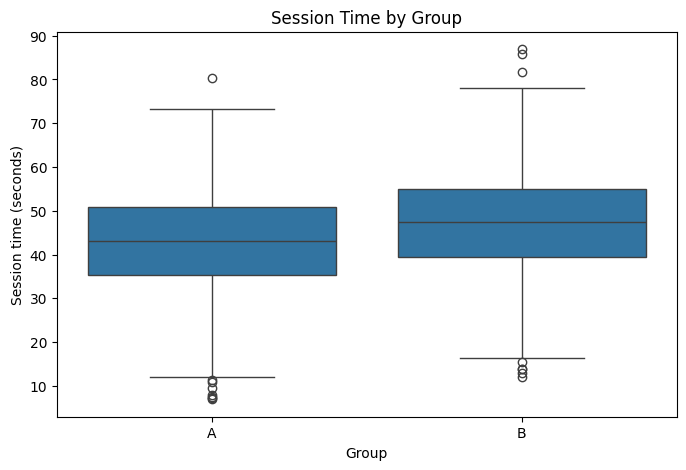

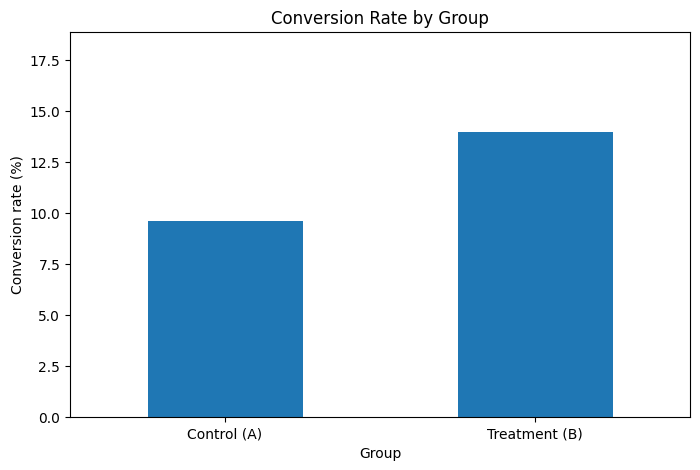

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="group", y="session_time_seconds", ax=ax)
ax.set_title("Session Time by Group")
ax.set_xlabel("Group")
ax.set_ylabel("Session time (seconds)")
plt.show()

rates = df.groupby("group")["converted"].mean() * 100
fig, ax = plt.subplots(figsize=(8, 5))
rates.plot(kind="bar", ax=ax)
ax.set_title("Conversion Rate by Group")
ax.set_xlabel("Group")
ax.set_ylabel("Conversion rate (%)")
ax.set_xticklabels(["Control (A)", "Treatment (B)"], rotation=0)
plt.ylim(0, max(rates) * 1.35)
plt.show()

## 5. Hypotheses

### For session time

- **H₀:** The two groups have the same average session time.
- **H₁:** The two groups have different average session times.

### For conversion

- **H₀:** Checkout version and conversion are not associated.
- **H₁:** Checkout version and conversion are associated.

We use:

```python
alpha = 0.05
```

Decision rule:

- p-value < 0.05 → reject H₀
- p-value >= 0.05 → fail to reject H₀

A large p-value does not prove the groups are identical.

In [6]:
alpha = 0.05
control_time = df.loc[df.group == "A", "session_time_seconds"]
treatment_time = df.loc[df.group == "B", "session_time_seconds"]

## 6. Independent two-sample t-test

A t-test compares the averages of two independent groups.

Our question:

> Is the average session time different between the old and new checkout pages?

We use Welch's version because it does not require the two groups to have equal variance.

In [7]:
t_stat, p_t = ttest_ind(control_time, treatment_time, equal_var=False)

print(f"Control mean: {control_time.mean():.2f} seconds")
print(f"Treatment mean: {treatment_time.mean():.2f} seconds")
print(f"Difference (B - A): {treatment_time.mean() - control_time.mean():.2f} seconds")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_t:.6f}")

if p_t < alpha:
    print("Decision: Reject H0.")
    print("Meaning: The average session times are statistically different.")
else:
    print("Decision: Fail to reject H0.")
    print("Meaning: We do not have enough evidence of a difference.")

Control mean: 43.19 seconds
Treatment mean: 47.46 seconds
Difference (B - A): 4.28 seconds
t-statistic: -7.9589
p-value: 0.000000
Decision: Reject H0.
Meaning: The average session times are statistically different.


## 7. Chi-square test

A chi-square test is useful for categories and counts.

Our categories are:

- Group A or Group B
- Converted or Did not convert

Question:

> Is conversion related to which checkout page the user saw?

In [8]:
table = pd.crosstab(df["group"], df["converted"])
table.columns = ["Did not convert", "Converted"]
display(table)

chi2, p_chi, dof, expected = chi2_contingency(table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_chi:.6f}")

if p_chi < alpha:
    print("Decision: Reject H0.")
    print("Meaning: Checkout version and conversion are statistically associated.")
else:
    print("Decision: Fail to reject H0.")
    print("Meaning: We do not have enough evidence of an association.")

,Did not convert,Converted
group,,
A,904,96
B,860,140


Chi-square statistic: 8.8829
Degrees of freedom: 1
p-value: 0.002878
Decision: Reject H0.
Meaning: Checkout version and conversion are statistically associated.


## 8. Conversion uplift

Statistical tests tell us whether a difference is supported by evidence.

Uplift tells us how large the difference is.

- **Absolute uplift:** treatment rate minus control rate
- **Relative uplift:** absolute uplift divided by control rate

In [9]:
control_rate = df.loc[df.group == "A", "converted"].mean()
treatment_rate = df.loc[df.group == "B", "converted"].mean()

absolute_uplift = treatment_rate - control_rate
relative_uplift = absolute_uplift / control_rate

print(f"Control conversion rate: {control_rate:.2%}")
print(f"Treatment conversion rate: {treatment_rate:.2%}")
print(f"Absolute uplift: {absolute_uplift:.2%} ({absolute_uplift*100:.2f} percentage points)")
print(f"Relative uplift: {relative_uplift:.2%}")

Control conversion rate: 9.60%
Treatment conversion rate: 14.00%
Absolute uplift: 4.40% (4.40 percentage points)
Relative uplift: 45.83%


## 9. Confidence interval for conversion difference

A confidence interval gives a range of plausible values for the true difference.

We calculate a 95% interval for:

```text
Treatment conversion rate - Control conversion rate
```

If the interval does not include zero, that supports evidence of a difference.

In [10]:
a = df.loc[df.group == "A", "converted"]
b = df.loc[df.group == "B", "converted"]

p_a, p_b = a.mean(), b.mean()
difference = p_b - p_a

se = np.sqrt(p_a*(1-p_a)/len(a) + p_b*(1-p_b)/len(b))
z = stats.norm.ppf(0.975)

lower = difference - z*se
upper = difference + z*se

print(f"Estimated difference: {difference:.2%}")
print(f"95% confidence interval: [{lower:.2%}, {upper:.2%}]")

Estimated difference: 4.40%
95% confidence interval: [1.58%, 7.22%]


## 10. Check results by device

A useful sanity check is to compare mobile and desktop users separately.

This does not replace a complete causal analysis, but it helps us see whether the pattern is similar across devices.

,device,group,users,conversions,conversion_rate,conversion_rate_percent
0,Desktop,A,329,34,0.1033,10.3343
1,Desktop,B,345,41,0.1188,11.8841
2,Mobile,A,671,62,0.0924,9.2399
3,Mobile,B,655,99,0.1511,15.1145


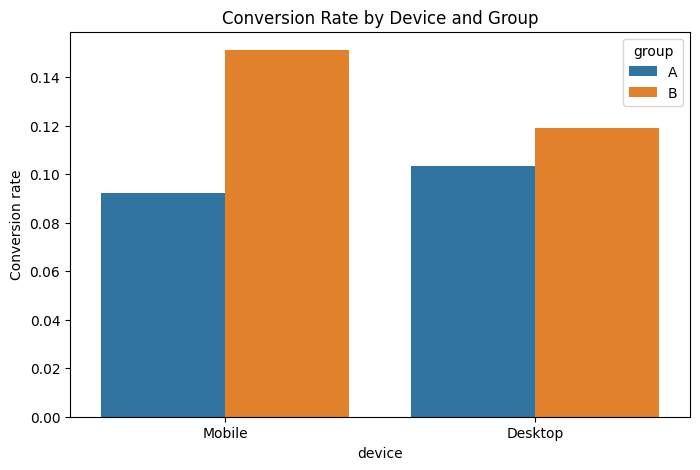

In [11]:
device_summary = df.groupby(["device", "group"]).agg(
    users=("user_id", "count"),
    conversions=("converted", "sum"),
    conversion_rate=("converted", "mean")
).reset_index()

device_summary["conversion_rate_percent"] = device_summary["conversion_rate"] * 100
display(device_summary)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df, x="device", y="converted", hue="group",
            estimator=np.mean, errorbar=None, ax=ax)
ax.set_title("Conversion Rate by Device and Group")
ax.set_ylabel("Conversion rate")
plt.show()

## 11. Statistical significance vs business significance

These are not the same.

### Statistical significance

Is the difference unlikely to be random chance?

### Business significance

Is the difference large enough to matter to the company?

A tiny uplift can be statistically significant with a huge sample but still not be worth the cost of implementation.

Before launching the new page, the company should consider:

- uplift size
- revenue impact
- implementation cost
- experiment duration
- random assignment
- device differences
- customer complaints or negative effects

## 12. Final conclusion

Use the printed results to complete this explanation:

> The treatment group had an average session time of **[value]** seconds compared with **[value]** seconds for the control group. The t-test p-value was **[value]**, so we **[rejected/failed to reject]** the null hypothesis at the 5% level.
>
> The treatment conversion rate was **[value]** compared with **[value]** for the control group. The chi-square p-value was **[value]**, indicating that checkout version and conversion were **[associated/not shown to be associated]**.
>
> The estimated absolute uplift was **[value]** percentage points, with a 95% confidence interval of **[lower]** to **[upper]**.
>
> A business decision should consider both statistical evidence and practical impact.

### Main lesson

> Data tells us what happened. Statistics helps us judge whether the difference may be more than random chance.

## 13. Interview questions

1. **What is a p-value?**  
   How surprising our result would be if the null hypothesis were true.

2. **What is the difference between a t-test and chi-square test?**  
   A t-test compares numerical averages. Chi-square examines categorical counts or relationships.

3. **Does p-value < 0.05 prove the alternative hypothesis?**  
   No. It gives evidence against the null hypothesis.

4. **Does statistical significance mean business success?**  
   No. We must also consider effect size, cost, and practical impact.

5. **Why do we need a control group?**  
   It gives us a comparison point for the old experience.

6. **What is conversion rate?**  
   The percentage of users who complete the desired action.